# Automated Trading using Python

Playground for algorithmic trading strategies.



### Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Data

In [2]:
# Sample data
np.random.seed(42)
n = 100
timestamps = pd.date_range("2025-01-01", periods=n, freq="h")

# Simulated day-ahead and intraday production forecasts [MW]
day_ahead_forecast = 1000 + np.random.normal(0, 20, n)
intraday_forecast = day_ahead_forecast + np.random.normal(0, 15, n)


# Simulate probabilistic price forecast quantiles from forecast std dev
forecast_std_dev =np.random.normal(10, 3, n)
forecast_mean_price = 80 + 0.1 * (day_ahead_forecast - intraday_forecast)
forecast_p10 = forecast_mean_price - 1.28 * forecast_std_dev * 0.1  # 10th percentile
forecast_p90 = forecast_mean_price + 1.28 * forecast_std_dev * 0.1  # 90th percentile

# Simulated intraday price [€/MWh]
intraday_price = 80 + 0.1 * (day_ahead_forecast - intraday_forecast) + np.random.normal(0, 2, n)

# Simulated next-hour price (for exit price)
exit_price = np.roll(intraday_price, -1)

df = pd.DataFrame({
    "timestamp": timestamps,
    "day_ahead_forecast": day_ahead_forecast,
    "intraday_forecast": intraday_forecast,
    "intraday_price": intraday_price,
    "forecast_std_dev": forecast_std_dev,
    "exit_price": exit_price,
    "forecast_p10": forecast_p10,
    "forecast_p90": forecast_p90
})

### Parameters

In [3]:
# Strategy parameters
threshold = 10  # MW
volume_per_trade = 1  # MWh
transaction_cost = 0.  # €/MWh

base_volume = 1.0  # MWh
min_size, max_size = 0.5, 3.0  # position size bounds

### Simple Strategy 

- Buy if intraday production forecast is lower than day-ahead: production is falling -> price likely to rise.
- Sell if intraday forecast is higher than day-ahead: production is rising -> price likely to fall.

Trade only if the difference exceeds a defined threshold.

Summary Statistics:
Mean PnL: -2.375 €/MWh
Std Dev: 60.020
Sharpe Ratio: -0.04
Win Rate: 29.29%
Number of trades: 52


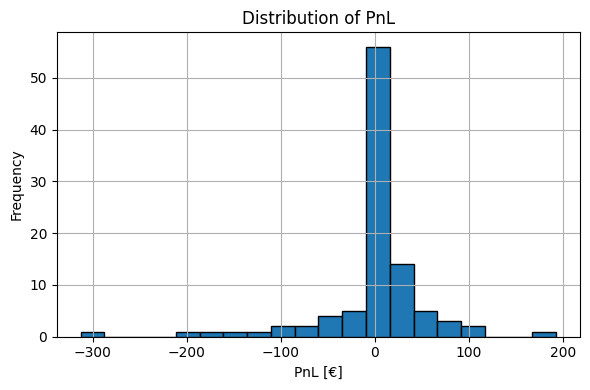

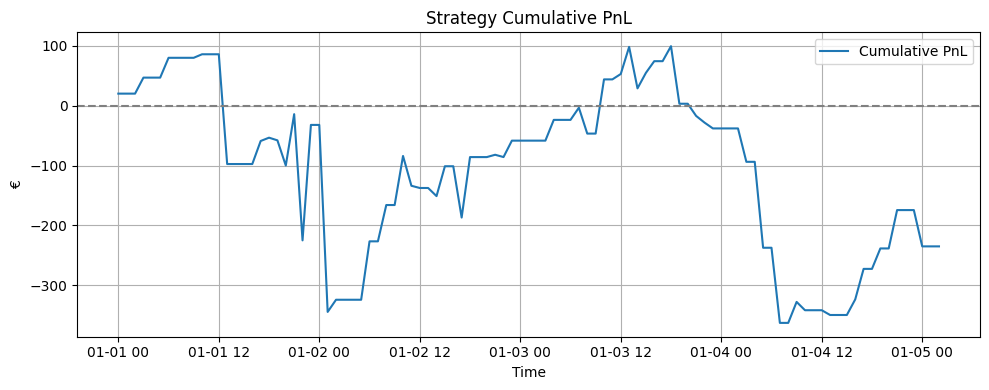

In [4]:
df["forecast_diff"] = df["intraday_forecast"] - df["day_ahead_forecast"]
df["signal"] = 0
df.loc[df["forecast_diff"] > threshold, "signal"] = -1  # More production -> prices fall -> sell
df.loc[df["forecast_diff"] < -threshold, "signal"] = 1  # Less production -> prices rise -> buy



df["exit_price"] = df["intraday_price"].shift(-1)
df["price_change"] = df["exit_price"] - df["intraday_price"]
df["pnl"] = df["signal"] * df["price_change"] * df["forecast_diff"] - abs(df["signal"]) * transaction_cost
# Cumulative PnL
df["cumulative_pnl"] = df["pnl"].cumsum()

pnl = df["pnl"].dropna()
print("Summary Statistics:")
print(f"Mean PnL: {pnl.mean():.3f} €/MWh")
print(f"Std Dev: {pnl.std():.3f}")
print(f"Sharpe Ratio: {pnl.mean() / pnl.std():.2f}")
print(f"Win Rate: {(pnl > 0).mean() * 100:.2f}%")
print(f"Number of trades: {np.count_nonzero(df['signal'])}")

plt.figure(figsize=(6, 4))
plt.hist(pnl, bins=20, edgecolor='k')
plt.title("Distribution of PnL")
plt.xlabel("PnL [€]")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["cumulative_pnl"], label="Cumulative PnL")
plt.axhline(0, linestyle='--', color='gray')
plt.title("Strategy Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("€")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Strategy 1: Signal Strength = Forecast Surprise (Normalized by Uncertainty)

- This creates a signal-to-noise ratio: large differences only matter if they are outside the uncertainty range.
- Trade only if |signal_strength| > threshold, e.g., standard deviations.

Summary Statistics:
Mean PnL: -3.218 €/MWh
Std Dev: 59.088
Sharpe Ratio: -0.05
Win Rate: 27.27%
Number of trades: 49


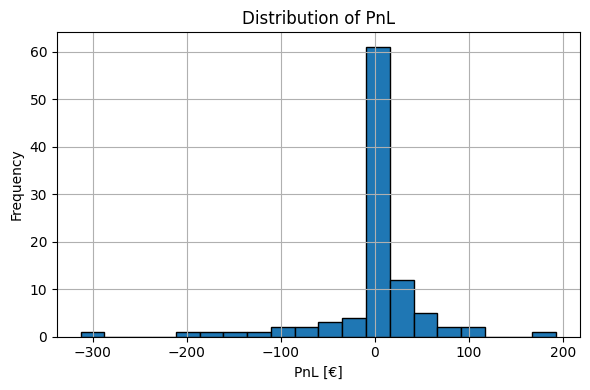

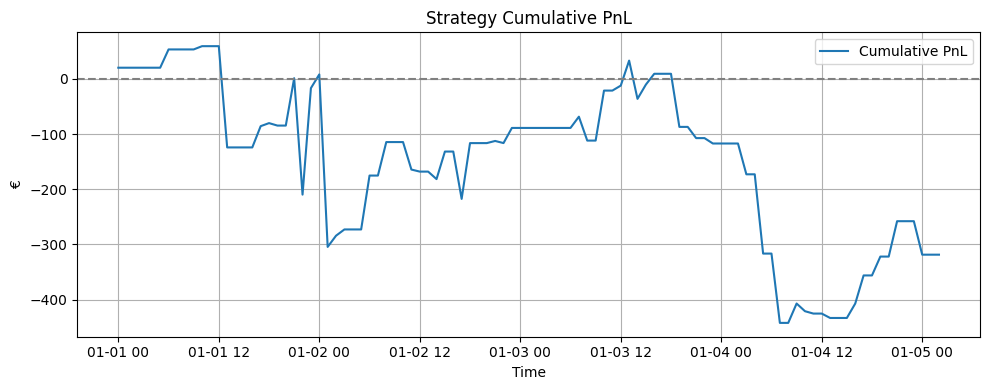

In [5]:
df["surprise"] = df["intraday_forecast"] - df["day_ahead_forecast"]
df["signal_strength"] = df["surprise"] / df["forecast_std_dev"]

# Threshold for action
threshold = 1.
df["signal"] = 0
df.loc[df["signal_strength"] > threshold, "signal"] = -1  # More production -> sell
df.loc[df["signal_strength"] < -threshold, "signal"] = 1  # Less production -> buy


df["exit_price"] = df["intraday_price"].shift(-1)
df["price_change"] = df["exit_price"] - df["intraday_price"]
df["pnl"] = df["signal"] * df["price_change"] * df["surprise"] - abs(df["signal"]) * transaction_cost
# Cumulative PnL
df["cumulative_pnl"] = df["pnl"].cumsum()

pnl = df["pnl"].dropna()
print("Summary Statistics:")
print(f"Mean PnL: {pnl.mean():.3f} €/MWh")
print(f"Std Dev: {pnl.std():.3f}")
print(f"Sharpe Ratio: {pnl.mean() / pnl.std():.2f}")
print(f"Win Rate: {(pnl > 0).mean() * 100:.2f}%")
print(f"Number of trades: {np.count_nonzero(df['signal'])}")

plt.figure(figsize=(6, 4))
plt.hist(pnl, bins=20, edgecolor='k')
plt.title("Distribution of PnL")
plt.xlabel("PnL [€]")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["cumulative_pnl"], label="Cumulative PnL")
plt.axhline(0, linestyle='--', color='gray')
plt.title("Strategy Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("€")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Strategy 2: Dynamic Position Sizing Based on Forecast Uncertainty

Scale the position size by the inverse of forecast standard deviation, i.e., take larger positions when the forecast is more certain, and smaller positions when it's more uncertain.

- When you're confident (small std), take larger positions.
- When uncertainty is high, trade smaller or not at all.

Summary Statistics:
Mean PnL: -0.641 €/MWh
Std Dev: 1.684
Sharpe Ratio: -0.38
Win Rate: 14.14%
Number of trades: 52


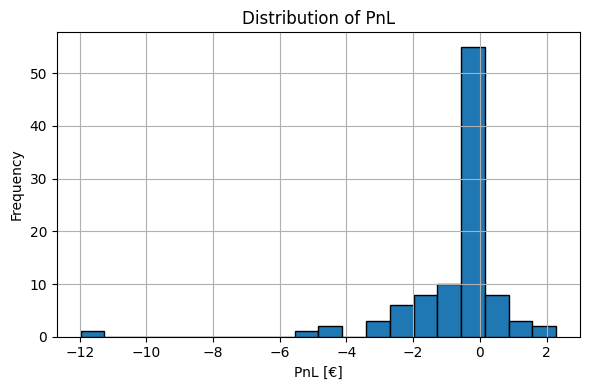

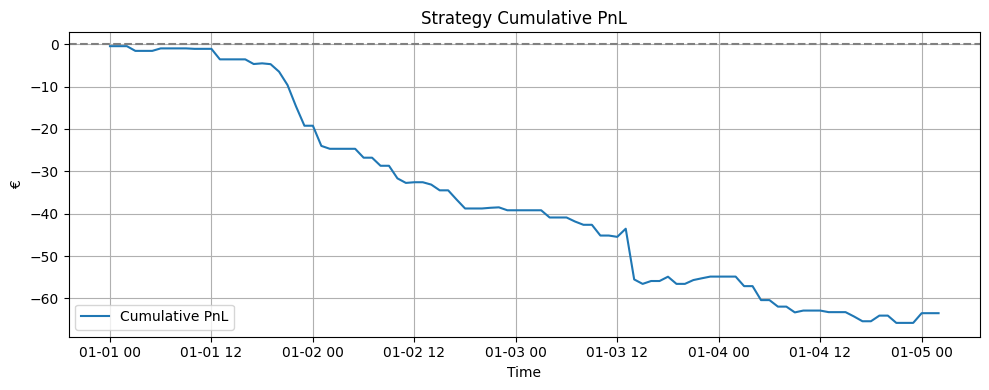

In [6]:
df["forecast_diff"] = df["intraday_forecast"] - df["day_ahead_forecast"]

threshold = 10
df["signal"] = 0
df.loc[df["forecast_diff"] > threshold, "signal"] = -1 # -> sell
df.loc[df["forecast_diff"] < -threshold, "signal"] = 1 # -> buy

# Position sizing based on inverse of uncertainty
df["position_size"] = np.clip(base_volume / df["forecast_std_dev"], min_size, max_size)


df["exit_price"] = df["intraday_price"].shift(-1)
df["price_change"] = df["exit_price"] - df["intraday_price"]
df["pnl"] = df["signal"] * df["price_change"] * df["position_size"] - abs(df["signal"]) * transaction_cost
# Cumulative PnL
df["cumulative_pnl"] = df["pnl"].cumsum()

pnl = df["pnl"].dropna()
print("Summary Statistics:")
print(f"Mean PnL: {pnl.mean():.3f} €/MWh")
print(f"Std Dev: {pnl.std():.3f}")
print(f"Sharpe Ratio: {pnl.mean() / pnl.std():.2f}")
print(f"Win Rate: {(pnl > 0).mean() * 100:.2f}%")
print(f"Number of trades: {np.count_nonzero(df['signal'])}")

plt.figure(figsize=(6, 4))
plt.hist(pnl, bins=20, edgecolor='k')
plt.title("Distribution of PnL")
plt.xlabel("PnL [€]")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["cumulative_pnl"], label="Cumulative PnL")
plt.axhline(0, linestyle='--', color='gray')
plt.title("Strategy Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("€")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Strategy 3: Use Probabilistic Quantiles 

Generate trading signals based on whether the market is behaving unexpectedly compared to what the forecast model predicted - not just in terms of the mean, but in terms of the distribution, e.g., through quantiles or ensembles.


Example: For a given delivery hour tomorrow
- P10 (10th percentile)
- P50 (median)
- P90 (90th percentile)
- Intraday Forecast or Market Price: Observe a new intraday forecast 

Simulate forecast quantiles (e.g., 10th and 90th percentiles) and trade only when the current market price is outside these bounds.

- Buy if market price < 10th percentile of forecast distribution -> price too low -> undervalued
- Sell if market price > 90th percentile -> price too high -> overvalued
- Else: do nothing

Summary Statistics:
Mean PnL: 4.148 €/MWh
Std Dev: 52.410
Sharpe Ratio: 0.08
Win Rate: 27.27%
Number of trades: 52


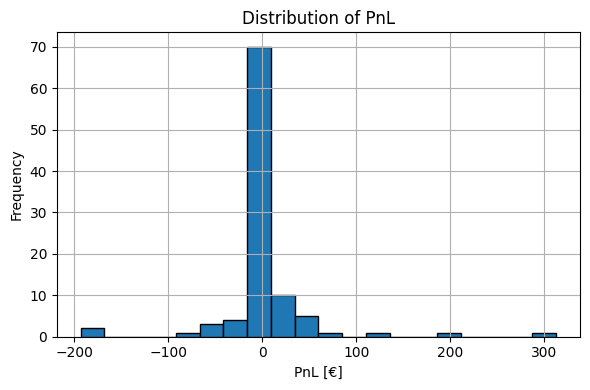

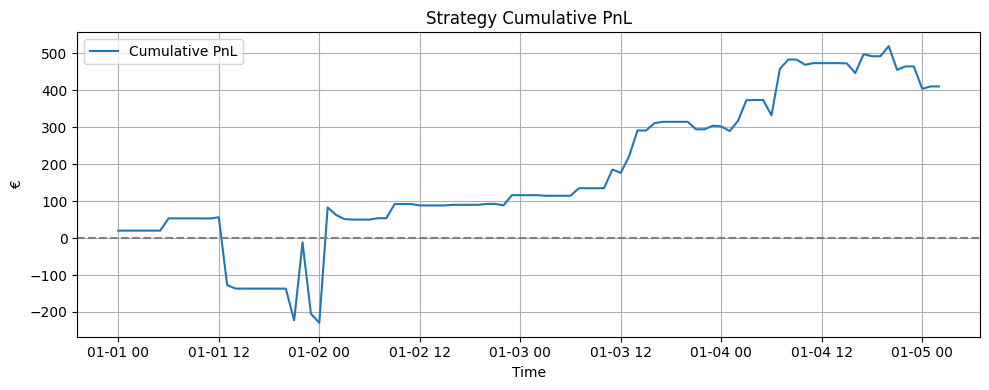

In [7]:
df["forecast_diff"] = df["intraday_forecast"] - df["day_ahead_forecast"]
# Trading signal based on quantile bounds
df["signal"] = 0
df.loc[df["intraday_price"] < df["forecast_p10"], "signal"] = 1   # -> buy
df.loc[df["intraday_price"] > df["forecast_p90"], "signal"] = -1  # -> sell



df["exit_price"] = df["intraday_price"].shift(-1)
df["price_change"] = df["exit_price"] - df["intraday_price"]
df["pnl"] = df["signal"] * df["price_change"] * df["forecast_diff"] - abs(df["signal"]) * transaction_cost
# Cumulative PnL
df["cumulative_pnl"] = df["pnl"].cumsum()

pnl = df["pnl"].dropna()
print("Summary Statistics:")
print(f"Mean PnL: {pnl.mean():.3f} €/MWh")
print(f"Std Dev: {pnl.std():.3f}")
print(f"Sharpe Ratio: {pnl.mean() / pnl.std():.2f}")
print(f"Win Rate: {(pnl > 0).mean() * 100:.2f}%")
print(f"Number of trades: {np.count_nonzero(df['signal'])}")

plt.figure(figsize=(6, 4))
plt.hist(pnl, bins=20, edgecolor='k')
plt.title("Distribution of PnL")
plt.xlabel("PnL [€]")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["cumulative_pnl"], label="Cumulative PnL")
plt.axhline(0, linestyle='--', color='gray')
plt.title("Strategy Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("€")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()